In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
from custom_vision_transformer import vit_b_16, ViT_B_16_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm
import training_parameters as params
from training_utils import *

In [3]:
print("Number of visible GPUs :", torch.cuda.device_count())

gpu_idx = 0
torch.cuda.set_device(gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print("GPU visible :", torch.cuda.current_device())
print("GPU name :", torch.cuda.get_device_name(torch.cuda.current_device()))

Number of visible GPUs : 3
Device : cuda
GPU visible : 0
GPU name : NVIDIA GeForce RTX 2080


/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU2 Quadro P400 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
Quadro P400 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Quadro P400 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [4]:
# --- load model ---
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).to(device)
model.eval();

In [5]:
# --- load data ---
train_loader, val_loader, mask = get_data_loaders(params.batch_size, params.img_size, device)

Number of training samples: 130000
Number of validation samples: 5000


In [14]:
def get_full_and_per_class_accuracy(model, dataloader, num_classes, device, mask):
    correct_global = 0
    total_global = 0

    correct_per_class = torch.zeros(num_classes, device=device)
    total_per_class = torch.zeros(num_classes, device=device)

    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(dataloader, total=len(dataloader)):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            outputs = outputs[:, mask]  # filtrer les indices si nécessaire
            _, predicted = torch.max(outputs, 1)

            # Exactitude globale
            total_global += labels.size(0)
            correct_global += (predicted == labels).sum().item()

            # Exactitude par classe
            for c in range(num_classes):
                class_mask = (labels == c)
                total_per_class[c] += class_mask.sum()
                correct_per_class[c] += ((predicted == c) & class_mask).sum()

    accuracy_global = correct_global / total_global
    accuracy_per_class = correct_per_class / total_per_class.clamp(min=1)

    return accuracy_global, accuracy_per_class.cpu()

In [15]:
accuracy_global, accuracy_per_class = get_full_and_per_class_accuracy(model, val_loader, 100, device, mask)

print(f"Accuracy: {accuracy_global*100:.2f}%")

worst_classes = torch.argsort(accuracy_per_class)

for i in worst_classes[:10]:
    print(f"Classe {i.item()} → accuracy = {accuracy_per_class[i].item():.2f}")

100%|██████████| 40/40 [00:25<00:00,  1.57it/s]

Accuracy: 88.58%
Classe 45 → accuracy = 0.36
Classe 39 → accuracy = 0.54
Classe 49 → accuracy = 0.62
Classe 34 → accuracy = 0.62
Classe 50 → accuracy = 0.64
Classe 43 → accuracy = 0.66
Classe 25 → accuracy = 0.68
Classe 35 → accuracy = 0.68
Classe 82 → accuracy = 0.70
Classe 38 → accuracy = 0.70


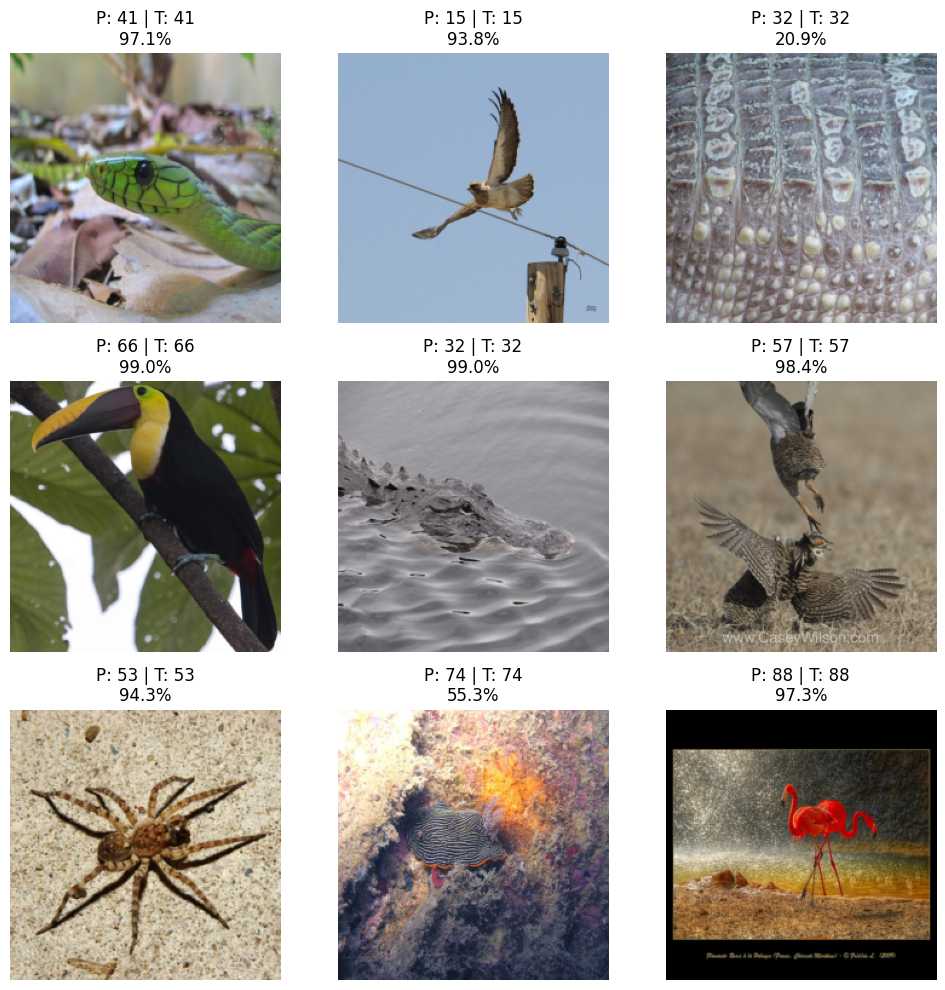

In [11]:
# --- récupérer des images ---
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

# limiter à 9 images (3x3)
num_display = min(9, images.size(0))
images = images[:num_display]
labels = labels[:num_display]

# --- faire les prédictions ---
with torch.no_grad():
    outputs = model(images)
    outputs = outputs[:, mask]  # filter out indices not in imagenette
    probs = F.softmax(outputs, dim=1)
    conf, predicted = torch.max(probs, dim=1)

# --- affichage en grille 3x3 ---
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i in range(num_display):
    img = images[i].cpu()

    # dénormalisation
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean

    img = img.permute(1,2,0).numpy()
    img = img.clip(0,1)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"P: {predicted[i].item()} | T: {labels[i].item()}\n{conf[i].item()*100:.1f}%"
    )

# cacher les cases vides si < 9 images
for j in range(num_display, 9):
    axes[j].axis('off')

plt.tight_layout()
plt.show()